In [15]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt

In [19]:
df=pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [23]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [29]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [31]:
print(df["mainroad"].unique())

print(df["furnishingstatus"].unique())

['yes' 'no']
['furnished' 'semi-furnished' 'unfurnished']


In [33]:
df = pd.get_dummies(
    df,
    drop_first=True
)

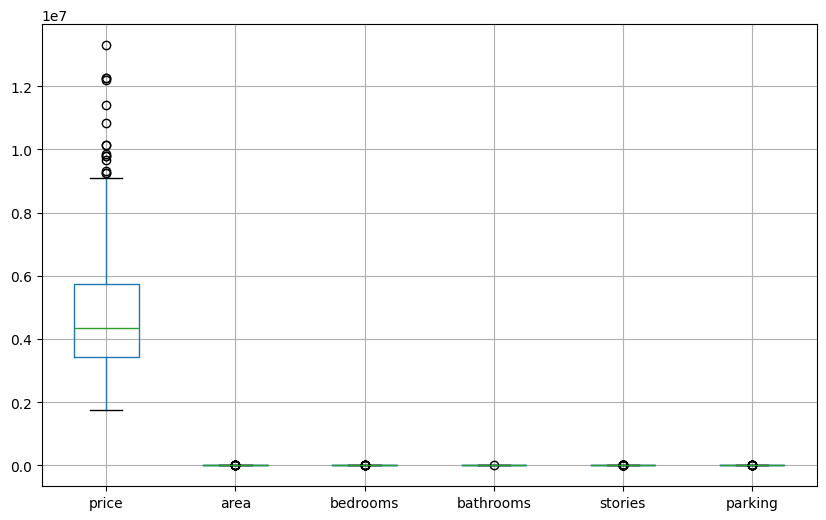

In [37]:
num_cols = [
    "price",
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

df[num_cols].boxplot(
    figsize=(10,6)
)

plt.show()

In [39]:
df[
[
"price",
"area",
"bedrooms",
"bathrooms",
"stories",
"parking"
]
].describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [43]:
X = df.drop(
    "price",
    axis=1
)

Y = df["price"]

In [53]:
train_x, test_x, train_y, test_y = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [45]:
model=LinearRegression()

In [55]:
model.fit(
    train_x,
    train_y
)

LinearRegression()

In [57]:
pred = model.predict(
    test_x
)

In [59]:
print("predicted",pred[:10])

predicted [5164653.90033967 7224722.29802167 3109863.24240338 4612075.3272256
 3294646.25725955 3532275.09556558 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782]


In [61]:
mse=mean_squared_error(
    test_y,
    pred
)
print("mean squared error :",mse)

mean squared error : 1754318687330.6643


In [63]:
mae=mean_absolute_error(
    test_y,
    pred
)
print("mean  absolute error :",mae)

mean  absolute error : 970043.4039201637


In [65]:
r2 = r2_score(
    test_y,
    pred
)

print("R² =", r2)

R² = 0.6529242642153184


In [67]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(
    coef.sort_values(
        "Coefficient",
        ascending=False
    )
)

                            Feature   Coefficient
2                         bathrooms  1.094445e+06
9               airconditioning_yes  7.914267e+05
8               hotwaterheating_yes  6.846499e+05
10                     prefarea_yes  6.298906e+05
3                           stories  4.074766e+05
7                      basement_yes  3.902512e+05
5                      mainroad_yes  3.679199e+05
6                     guestroom_yes  2.316100e+05
4                           parking  2.248419e+05
1                          bedrooms  7.677870e+04
0                              area  2.359688e+02
11  furnishingstatus_semi-furnished -1.268818e+05
12     furnishingstatus_unfurnished -4.136451e+05


In [71]:
from sklearn.metrics import r2_score

pred = model.predict(test_x)

print(
    r2_score(
        test_y,
        pred
    )
)

0.6529242642153184


In [73]:
print(
mean_absolute_error(
test_y,
pred
))

970043.4039201637


#### import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
      [test_y.min(), test_y.max()],
      [test_y.min(), test_y.max()],
      linestyle="--",
      color="red"
)
    
plt.scatter(
    test_y,
    pred
)

plt.xlabel(
    "Actual Price"
)

plt.ylabel(
    "Predicted Price"
)

plt.title(
    "Actual vs Predicted"
)
plt.grid(alpha=0.5)
plt.legend()
plt.show()